# Importação de Bibliotecas

In [1]:
#install
#!pip install -q -U matplotlib numpy pandas plotly scikit-learn scipy seaborn shap statsmodels xgboost

In [2]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Obtenção da tabela

In [3]:
# obter o csv do arquivo com separação ';'
dataset_cap02 = pd.read_csv('15-dataset/dataset.csv', sep=';')

# Análise Exploratória de Dados (EDA)

In [4]:
# verificar o cabeçario
dataset_cap02.head()

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Regiao,Pais,Product ID,Categoria,SubCategoria,Total_Vendas,Quantidade,Desconto,Lucro,Prioridade
0,CA-2012-124891,31-07-2012,RH-19495,Consumidor,New York,United States,TEC-AC-10003033,Tecnologia,Accessories,"2309,65",7,0,"762,1845",Critico
1,IN-2013-77878,05-02-2013,JR-16210,Corporativo,New South Wales,Australia,FUR-CH-10003950,Moveis,Chairs,3709395,9,"0,1",-288765,Critico
2,IN-2013-71249,17-10-2013,CR-12730,Consumidor,Queensland,Australia,TEC-PH-10004664,Tecnologia,Phones,5175171,9,"0,1",919971,Medio
3,ES-2013-1579342,28-01-2013,KM-16375,Home Office,Berlin,Germany,TEC-PH-10004583,Tecnologia,Phones,"2892,51",5,"0,1","-96,54",Medio
4,SG-2013-4320,05-11-2013,RH-9495,Consumidor,Dakar,Senegal,TEC-SHA-10000501,Tecnologia,Copiers,"2832,96",8,0,"311,52",Critico


In [5]:
#verificar o fim ou calda
dataset_cap02.tail()

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Regiao,Pais,Product ID,Categoria,SubCategoria,Total_Vendas,Quantidade,Desconto,Lucro,Prioridade
51285,IN-2014-62366,19-06-2014,KE-16420,Corporativo,Hiroshima,Japan,OFF-FA-10000746,Suprimentos,Fasteners,"65,1",5,0,"4,5",Medio
51286,US-2014-102288,20-06-2014,ZC-21910,Consumidor,Texas,United States,OFF-AP-10002906,Suprimentos,Appliances,444,1,"0,8","-1,11",Medio
51287,US-2013-155768,02-12-2013,LB-16795,Home Office,California,United States,OFF-EN-10001219,Suprimentos,Envelopes,"22,92",3,0,"11,2308",Alto
51288,MX-2012-140767,18-02-2012,RB-19795,Home Office,São Paulo,Brazil,OFF-BI-10000806,Suprimentos,Binders,"13,44",2,0,"2,4",Medio
51289,MX-2012-134460,22-05-2012,MC-18100,Consumidor,Managua,Nicaragua,OFF-PA-10004155,Suprimentos,Paper,"61,38",3,0,"1,8",Alto


In [6]:
# informações da tabela
dataset_cap02.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   ID_Pedido     51290 non-null  str  
 1   Data_Pedido   51290 non-null  str  
 2   ID_Cliente    51290 non-null  str  
 3   Segmento      51290 non-null  str  
 4   Regiao        51290 non-null  str  
 5   Pais          51290 non-null  str  
 6   Product ID    51290 non-null  str  
 7   Categoria     51290 non-null  str  
 8   SubCategoria  51290 non-null  str  
 9   Total_Vendas  51290 non-null  str  
 10  Quantidade    51290 non-null  int64
 11  Desconto      51290 non-null  str  
 12  Lucro         51290 non-null  str  
 13  Prioridade    51290 non-null  str  
dtypes: int64(1), str(13)
memory usage: 5.5 MB


Observamos que a tabela tem:

- 51290 entradas
- 14 colunas
  - 13 str
  - 1 int64
- Non-null não teve em nenhuma então quer dizer que todos os dados estão completos


Agora observação da .head():

- 'Total_Vendas','Quantidade','Desconto','Lucro', são colunas numericas
- 'Total_Vendas','Desconto','Lucro', são flutuantes, pois tem casas decimais
- 'Data_Pedido' é do tipo data

In [7]:
print(dataset_cap02.isna().sum())

ID_Pedido       0
Data_Pedido     0
ID_Cliente      0
Segmento        0
Regiao          0
Pais            0
Product ID      0
Categoria       0
SubCategoria    0
Total_Vendas    0
Quantidade      0
Desconto        0
Lucro           0
Prioridade      0
dtype: int64


Não tem nenhum dado faltante

In [8]:
print(dataset_cap02.duplicated().sum())

9


Tem 9 dados duplicados

# Limpeza

## Correção dos tipos de dados

In [9]:
dataset_cap02_limpo = dataset_cap02.copy()

In [10]:
#converter ',' em '.', pois em python numeros float usa '.' para casas numericas e não ','
colunas_float = ['Total_Vendas','Desconto','Lucro']
dataset_cap02_limpo[colunas_float] = dataset_cap02_limpo[colunas_float].apply( lambda x : x.str.replace(',','.', regex=False))

In [11]:
dataset_cap02_limpo[colunas_float] = dataset_cap02_limpo[colunas_float].apply(pd.to_numeric, errors= 'coerce')

In [12]:
dataset_cap02_limpo['Data_Pedido'] = pd.to_datetime(dataset_cap02_limpo['Data_Pedido'], errors= 'coerce', dayfirst=True, format="%d-%m-%Y")

In [13]:
dataset_cap02_limpo.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ID_Pedido     51290 non-null  str           
 1   Data_Pedido   51290 non-null  datetime64[us]
 2   ID_Cliente    51290 non-null  str           
 3   Segmento      51290 non-null  str           
 4   Regiao        51290 non-null  str           
 5   Pais          51290 non-null  str           
 6   Product ID    51290 non-null  str           
 7   Categoria     51290 non-null  str           
 8   SubCategoria  51290 non-null  str           
 9   Total_Vendas  51290 non-null  float64       
 10  Quantidade    51290 non-null  int64         
 11  Desconto      51290 non-null  float64       
 12  Lucro         51290 non-null  float64       
 13  Prioridade    51290 non-null  str           
dtypes: datetime64[us](1), float64(3), int64(1), str(9)
memory usage: 5.5 MB


In [14]:
dataset_cap02_limpo.head()

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Regiao,Pais,Product ID,Categoria,SubCategoria,Total_Vendas,Quantidade,Desconto,Lucro,Prioridade
0,CA-2012-124891,2012-07-31,RH-19495,Consumidor,New York,United States,TEC-AC-10003033,Tecnologia,Accessories,2309.65,7,0.0,762.1845,Critico
1,IN-2013-77878,2013-02-05,JR-16210,Corporativo,New South Wales,Australia,FUR-CH-10003950,Moveis,Chairs,3709395.00,9,0.1,-288765.0000,Critico
2,IN-2013-71249,2013-10-17,CR-12730,Consumidor,Queensland,Australia,TEC-PH-10004664,Tecnologia,Phones,5175171.00,9,0.1,919971.0000,Medio
3,ES-2013-1579342,2013-01-28,KM-16375,Home Office,Berlin,Germany,TEC-PH-10004583,Tecnologia,Phones,2892.51,5,0.1,-96.5400,Medio
4,SG-2013-4320,2013-11-05,RH-9495,Consumidor,Dakar,Senegal,TEC-SHA-10000501,Tecnologia,Copiers,2832.96,8,0.0,311.5200,Critico


Verificar se as mudanças do tipos de dados foram implantados

In [15]:
dataset_cap02_limpo.describe()

,Data_Pedido,Total_Vendas,Quantidade,Desconto,Lucro
count,51290,5.129000e+04,51290.000000,51290.000000,5.129000e+04
mean,2013-05-11 21:26:49.155780,6.481949e+04,3.476545,1.406178,-1.336647e+03
min,2011-01-01 00:00:00,9.900000e-01,1.000000,0.000000,-6.599978e+06
25%,2012-06-19 00:00:00,4.944000e+01,2.000000,0.000000,0.000000e+00
50%,2013-07-08 00:00:00,1.936200e+02,3.000000,0.000000,1.182000e+01
75%,2014-05-22 00:00:00,8.904000e+03,5.000000,0.200000,6.762000e+01
max,2014-12-31 00:00:00,1.119997e+07,14.000000,602.000000,8.399976e+06
std,NaN,2.612405e+05,2.278766,22.824255,9.823915e+04


In [16]:
dataset_cap02_limpo.describe(include=[str])

,ID_Pedido,ID_Cliente,Segmento,Regiao,Pais,Product ID,Categoria,SubCategoria,Prioridade
count,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,25035,1590,3,1094,147,10292,3,17,4
top,CA-2014-100111,PO-18850,Consumidor,California,United States,OFF-AR-10003651,Suprimentos,Binders,Medio
freq,14,97,26518,2001,9994,35,31273,6152,29433


## Tratando Valores NaN

## Tratando Valores Duplicados

In [17]:
dataset_cap02_limpo.drop_duplicates(inplace=True)

In [18]:
print(dataset_cap02_limpo.duplicated().sum())

0


In [19]:
dataset_cap02_limpo.info()

<class 'pandas.DataFrame'>
Index: 51281 entries, 0 to 51289
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ID_Pedido     51281 non-null  str           
 1   Data_Pedido   51281 non-null  datetime64[us]
 2   ID_Cliente    51281 non-null  str           
 3   Segmento      51281 non-null  str           
 4   Regiao        51281 non-null  str           
 5   Pais          51281 non-null  str           
 6   Product ID    51281 non-null  str           
 7   Categoria     51281 non-null  str           
 8   SubCategoria  51281 non-null  str           
 9   Total_Vendas  51281 non-null  float64       
 10  Quantidade    51281 non-null  int64         
 11  Desconto      51281 non-null  float64       
 12  Lucro         51281 non-null  float64       
 13  Prioridade    51281 non-null  str           
dtypes: datetime64[us](1), float64(3), int64(1), str(9)
memory usage: 5.9 MB


## Tratamento de Dados Outliers

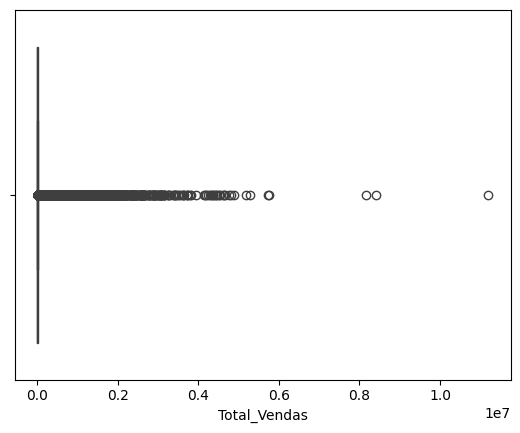

In [20]:
sns.boxplot(x = dataset_cap02_limpo['Total_Vendas'])
plt.show()

In [21]:
vendas_multiplas = dataset_cap02_limpo[
    dataset_cap02_limpo['Product ID']
        .isin(dataset_cap02_limpo['Product ID']
            .value_counts()[dataset_cap02_limpo['Product ID']
                .value_counts() > 1]
                    .index
                        .tolist()
             )][['Product ID', 'Total_Vendas', 'Lucro']]

In [22]:
vendas_multiplas_sem_decimais = vendas_multiplas[vendas_multiplas['Total_Vendas'].apply(lambda x: x%1 == 0)]['Total_Vendas']
vendas_multiplas_sem_decimais

1        3709395.0
2        5175171.0
5        2862675.0
9        4297644.0
15       1869588.0
           ...    
51278       5364.0
51279       9612.0
51280      34128.0
51281         84.0
51286        444.0
Name: Total_Vendas, Length: 14584, dtype: float64

In [23]:
vendas_multiplas_com_decimais = vendas_multiplas[vendas_multiplas['Total_Vendas'].apply(lambda x: x%1 != 0)]['Total_Vendas']
vendas_multiplas_com_decimais

0        2309.65
3        2892.51
6        1822.08
7        5244.84
8        5083.96
          ...   
51284      58.05
51285      65.10
51287      22.92
51288      13.44
51289      61.38
Name: Total_Vendas, Length: 35277, dtype: float64

In [24]:
dataset_cap02_limpo['valor_unitario'] = dataset_cap02_limpo['Total_Vendas']/dataset_cap02_limpo['Quantidade']

In [25]:
dataset_cap02_limpo['valor_unitario'] = pd.to_numeric(dataset_cap02_limpo['valor_unitario'], errors='coerce')

In [26]:
#dataset_cap02_limpo

In [27]:
dataset_cap02_limpo.info()

<class 'pandas.DataFrame'>
Index: 51281 entries, 0 to 51289
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       51281 non-null  str           
 1   Data_Pedido     51281 non-null  datetime64[us]
 2   ID_Cliente      51281 non-null  str           
 3   Segmento        51281 non-null  str           
 4   Regiao          51281 non-null  str           
 5   Pais            51281 non-null  str           
 6   Product ID      51281 non-null  str           
 7   Categoria       51281 non-null  str           
 8   SubCategoria    51281 non-null  str           
 9   Total_Vendas    51281 non-null  float64       
 10  Quantidade      51281 non-null  int64         
 11  Desconto        51281 non-null  float64       
 12  Lucro           51281 non-null  float64       
 13  Prioridade      51281 non-null  str           
 14  valor_unitario  51281 non-null  float64       
dtypes: datetime64[us](

In [28]:
def medidas_data(data, com_decimal, coluna):
    data_media = data.loc[com_decimal.index, coluna]
    
    data_media.mean()
    
    sigma_3 = data_media.mean() + 3 * data_media.std()
    
    sigma_2 = data_media.mean() + 2 * data_media.std()
    
    sigma_1 = data_media.mean() + 1 * data_media.std()
    
    media = data_media.mean()
    
    mediana = data_media.median()
    
    quartio_3 = data_media.quantile(0.75)
    
    quartio_80 = data_media.quantile(0.8)
    
    quartio_90 = data_media.quantile(0.9)
    
    quartio_maximo = data_media.quantile(1)
    
    print(f'mediana:{mediana: ,.2f}, media:{media: ,.2f}, 75%:{quartio_3: ,.2f}, 80%:{quartio_80: ,.2f}, 90%:{quartio_90: ,.2f}, maximo:{quartio_maximo: ,.2f}, sigma_1:{sigma_1: ,.2f}, sigma_2:{sigma_2: ,.2f}, sigma_3:{sigma_3: ,.2f}')

    quartio_minimo = data_media.quantile(0)
    
    if quartio_minimo < 0:

        quartio_1 = data_media.quantile(0.25)
        
        quartio_20 = data_media.quantile(0.2)
        
        quartio_10 = data_media.quantile(0.1)
    
        print(f'25%:{quartio_1: ,.2f}, 20%:{quartio_20: ,.2f}, 10%:{quartio_10: ,.2f}, minimo:{quartio_minimo: ,.2f}')

medidas_data(dataset_cap02_limpo, vendas_multiplas_com_decimais, 'valor_unitario')

mediana: 29.91, media: 71.95, 75%: 81.99, 80%: 112.20, 90%: 182.16, maximo: 3,499.99, sigma_1: 183.73, sigma_2: 295.51, sigma_3: 407.29


In [29]:
dataset_cap02_limpo.loc[dataset_cap02_limpo['Total_Vendas'].apply(lambda x: x%1 == 0)]['Total_Vendas']

1        3709395.0
2        5175171.0
5        2862675.0
9        4297644.0
15       1869588.0
           ...    
51278       5364.0
51279       9612.0
51280      34128.0
51281         84.0
51286        444.0
Name: Total_Vendas, Length: 15158, dtype: float64

In [30]:
vendas_sem_decimal = dataset_cap02_limpo.loc[dataset_cap02_limpo['Total_Vendas'].apply(lambda x: x%1 == 0)]['Total_Vendas']/100
vendas_sem_decimal

1        37093.95
2        51751.71
5        28626.75
9        42976.44
15       18695.88
           ...   
51278       53.64
51279       96.12
51280      341.28
51281        0.84
51286        4.44
Name: Total_Vendas, Length: 15158, dtype: float64

In [31]:
dataset_cap02_limpo.loc[vendas_sem_decimal.index, 'Total_Vendas'] = vendas_sem_decimal
dataset_cap02_limpo.loc[vendas_sem_decimal.index, 'Total_Vendas']

1        37093.95
2        51751.71
5        28626.75
9        42976.44
15       18695.88
           ...   
51278       53.64
51279       96.12
51280      341.28
51281        0.84
51286        4.44
Name: Total_Vendas, Length: 15158, dtype: float64

In [32]:
valor_unitario_novo = dataset_cap02_limpo.loc[vendas_sem_decimal.index, 'Total_Vendas']/dataset_cap02_limpo.loc[vendas_sem_decimal.index, 'Quantidade']
valor_unitario_novo

1        4121.550
2        5750.190
5        5725.350
9        3305.880
15       4673.970
           ...   
51278      53.640
51279      48.060
51280      56.880
51281       0.168
51286       4.440
Length: 15158, dtype: float64

In [33]:
dataset_cap02_limpo.loc[vendas_sem_decimal.index, 'valor_unitario'] = valor_unitario_novo
dataset_cap02_limpo.loc[vendas_sem_decimal.index, 'valor_unitario']

1        4121.550
2        5750.190
5        5725.350
9        3305.880
15       4673.970
           ...   
51278      53.640
51279      48.060
51280      56.880
51281       0.168
51286       4.440
Name: valor_unitario, Length: 15158, dtype: float64

In [34]:
#dataset_cap02_limpo[dataset_cap02_limpo['valor_unitario'] > 3500]

In [35]:
novo_valor_total = dataset_cap02_limpo[dataset_cap02_limpo['valor_unitario'] > 3500]['Total_Vendas']/10
novo_valor_total

1        3709.395
2        5175.171
5        2862.675
15       1869.588
21       2735.952
           ...   
24690     413.451
30439    2039.796
30509    1654.668
31345     409.968
41211    1639.089
Name: Total_Vendas, Length: 391, dtype: float64

In [36]:
### RESET index ####



#dataset_cap02_limpo = dataset_cap02_limpo.reset_index(drop=True)

In [37]:
dataset_cap02_limpo.loc[novo_valor_total.index, 'Total_Vendas'] = novo_valor_total
dataset_cap02_limpo['valor_unitario'] = dataset_cap02_limpo['Total_Vendas']/dataset_cap02_limpo['Quantidade']
dataset_cap02_limpo.loc[novo_valor_total.index, 'valor_unitario']

1        412.155
2        575.019
5        572.535
15       467.397
21       455.992
          ...   
24690    413.451
30439    509.949
30509    413.667
31345    409.968
41211    546.363
Name: valor_unitario, Length: 391, dtype: float64

In [38]:
dataset_cap02_limpo.info()

<class 'pandas.DataFrame'>
Index: 51281 entries, 0 to 51289
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       51281 non-null  str           
 1   Data_Pedido     51281 non-null  datetime64[us]
 2   ID_Cliente      51281 non-null  str           
 3   Segmento        51281 non-null  str           
 4   Regiao          51281 non-null  str           
 5   Pais            51281 non-null  str           
 6   Product ID      51281 non-null  str           
 7   Categoria       51281 non-null  str           
 8   SubCategoria    51281 non-null  str           
 9   Total_Vendas    51281 non-null  float64       
 10  Quantidade      51281 non-null  int64         
 11  Desconto        51281 non-null  float64       
 12  Lucro           51281 non-null  float64       
 13  Prioridade      51281 non-null  str           
 14  valor_unitario  51281 non-null  float64       
dtypes: datetime64[us](

In [39]:
#dataset_cap02_limpo.loc[novo_valor_total.index,'Total_Vendas':]

In [40]:
dataset_cap02_limpo.info()

<class 'pandas.DataFrame'>
Index: 51281 entries, 0 to 51289
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       51281 non-null  str           
 1   Data_Pedido     51281 non-null  datetime64[us]
 2   ID_Cliente      51281 non-null  str           
 3   Segmento        51281 non-null  str           
 4   Regiao          51281 non-null  str           
 5   Pais            51281 non-null  str           
 6   Product ID      51281 non-null  str           
 7   Categoria       51281 non-null  str           
 8   SubCategoria    51281 non-null  str           
 9   Total_Vendas    51281 non-null  float64       
 10  Quantidade      51281 non-null  int64         
 11  Desconto        51281 non-null  float64       
 12  Lucro           51281 non-null  float64       
 13  Prioridade      51281 non-null  str           
 14  valor_unitario  51281 non-null  float64       
dtypes: datetime64[us](

In [41]:
dataset_cap02_limpo['valor_unitario'].describe()

count    51281.000000
mean       203.157981
std        428.142452
min          0.016000
25%         16.110000
50%         48.940000
75%        170.370000
max       3499.990000
Name: valor_unitario, dtype: float64

In [42]:
dataset_cap02_limpo['Total_Vendas'].describe()

count    51281.000000
mean       706.289225
std       1899.739684
min          0.030000
25%         44.480000
50%        140.940000
75%        513.540000
max      47484.360000
Name: Total_Vendas, dtype: float64

In [43]:
lucro_multiplos_com_decimais = vendas_multiplas[vendas_multiplas['Lucro'].apply(lambda x: x%1 != 0)]['Lucro']
lucro_multiplos_com_decimais

0         762.1845
3         -96.5400
6         564.8400
7         996.4800
9       -1862.3124
           ...    
51285       4.5000
51286      -1.1100
51287      11.2308
51288       2.4000
51289       1.8000
Name: Lucro, Length: 36126, dtype: float64

In [44]:
medidas_data(dataset_cap02_limpo, lucro_multiplos_com_decimais, 'Lucro')

mediana: 12.71, media: 40.79, 75%: 42.84, 80%: 57.75, 90%: 122.81, maximo: 6,719.98, sigma_1: 204.25, sigma_2: 367.70, sigma_3: 531.16
25%: 3.06, 20%: 1.65, 10%:-10.34, minimo:-3,701.89


In [45]:
lucro_sem_decimal = dataset_cap02_limpo.loc[dataset_cap02_limpo['Lucro'].apply(lambda x: x%1 == 0)]['Lucro']/100
lucro_sem_decimal

1        -2887.65
2         9199.71
5         7632.75
8        19064.85
10         832.81
           ...   
51277       80.73
51278      -64.56
51279     -211.68
51280     -495.72
51282        0.08
Name: Lucro, Length: 14283, dtype: float64

In [46]:
dataset_cap02_limpo.loc[lucro_sem_decimal.index, ['Lucro']] = lucro_sem_decimal
dataset_cap02_limpo['Lucro']

0         762.1845
1       -2887.6500
2        9199.7100
3         -96.5400
4         311.5200
           ...    
51285       4.5000
51286      -1.1100
51287      11.2308
51288       2.4000
51289       1.8000
Name: Lucro, Length: 51281, dtype: float64

In [47]:
while True:
    requisito = (dataset_cap02_limpo['Lucro'] > 6719.98) | (dataset_cap02_limpo['Lucro'] < -3701.89)
    
    if requisito.any():
        dataset_cap02_limpo.loc[requisito, 'Lucro'] /= 10
    else:
        break

In [48]:
(dataset_cap02_limpo['Lucro'] > 6719.98) | (dataset_cap02_limpo['Lucro'] < -3701.89)

0        False
1        False
2        False
3        False
4        False
         ...  
51285    False
51286    False
51287    False
51288    False
51289    False
Name: Lucro, Length: 51281, dtype: bool

### Os dados obtidos estão com problemas, pois ao converter os valores do xlsx para csv, houve problemas na conversão dos valores numéricos, como a falta de casas decimais em alguns casos. Desse modo, mesmo realizando este tratamento, pode ser que os valores estejam diferentes dos reais.

### É possível fazer a comparação preço a preço para obter os valores totais mais corretos, porém há dados únicos que não permitem essa comparação. Vou refazer a análise com os dados corretos em outro notebook.